# Evaluarea modelelor pentru detectarea mesajelor spam
Acest notebook verifica cat de bine functioneaza mai multe modele care incearca sa distinga spam de mesajele normale. Vom testa patru metode diferite (Logistic Regression, Naive Bayes, Decision Tree si Linear SVC) si vom compara rezultatele lor folosind masuratori importante precum acuratetea, precizia, recall-ul, scorul F1 si matricea de confuzie. Scopul este sa vedem care model este mai de incredere pentru detectarea spamului.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Incarcarea si analiza setului de date
Incarcam fisierul 'message.csv' si verificam structura datelor, valorile lipsa si etichetele existente.

In [2]:
df = pd.read_csv("messages.csv")
df.head()

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.isna().sum()
df["category"].unique()
df["category"].value_counts()

category
ham         4491
spam         731
not spam     236
Name: count, dtype: int64

# Curatarea datelor
Eliminam valorile lipsa, standardizam etichetele si pastram doar 'spam' si 'ham'.

In [4]:
df = df.dropna(subset=["message", "category"])
df["category"] = df["category"].str.lower()
df = df[df["category"].isin(["spam", "ham"])]
df["category"].value_counts()

category
ham     4449
spam     722
Name: count, dtype: int64

# Impartirea datelor in antrenare si testare

In [7]:
from sklearn.model_selection import train_test_split

X = df["message"]
Y = df["category"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

len(X_train), len(X_test)

(4136, 1035)

# Vectorizarea textului cu TF-IDF

In [8]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Antrenarea mai multor modele

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial NB": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Linear SVC": LinearSVC()
}

results = {}

for name, model in models.items():
    print(f"=== {name} ===")
    model.fit(X_train_vec, Y_train)
    Y_pred = model.predict(X_test_vec)

    acc = accuracy_score(Y_test, Y_pred)
    print(f"Acuratete: {acc:.4f}")
    print(classification_report(Y_test, Y_pred))

    cm = confusion_matrix(Y_test, Y_pred, labels=["spam", "ham"])
    results[name] = {"model": model, "accuracy": acc, "cm": cm}
    print("-" * 50)

=== Logistic Regression ===
Acuratete: 0.9671
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       890
        spam       0.97      0.79      0.87       145

    accuracy                           0.97      1035
   macro avg       0.97      0.89      0.93      1035
weighted avg       0.97      0.97      0.97      1035

--------------------------------------------------
=== Multinomial NB ===
Acuratete: 0.9594
              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       890
        spam       1.00      0.71      0.83       145

    accuracy                           0.96      1035
   macro avg       0.98      0.86      0.90      1035
weighted avg       0.96      0.96      0.96      1035

--------------------------------------------------
=== Decision Tree ===
Acuratete: 0.9739
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       890
        

# Matrici de confuzie

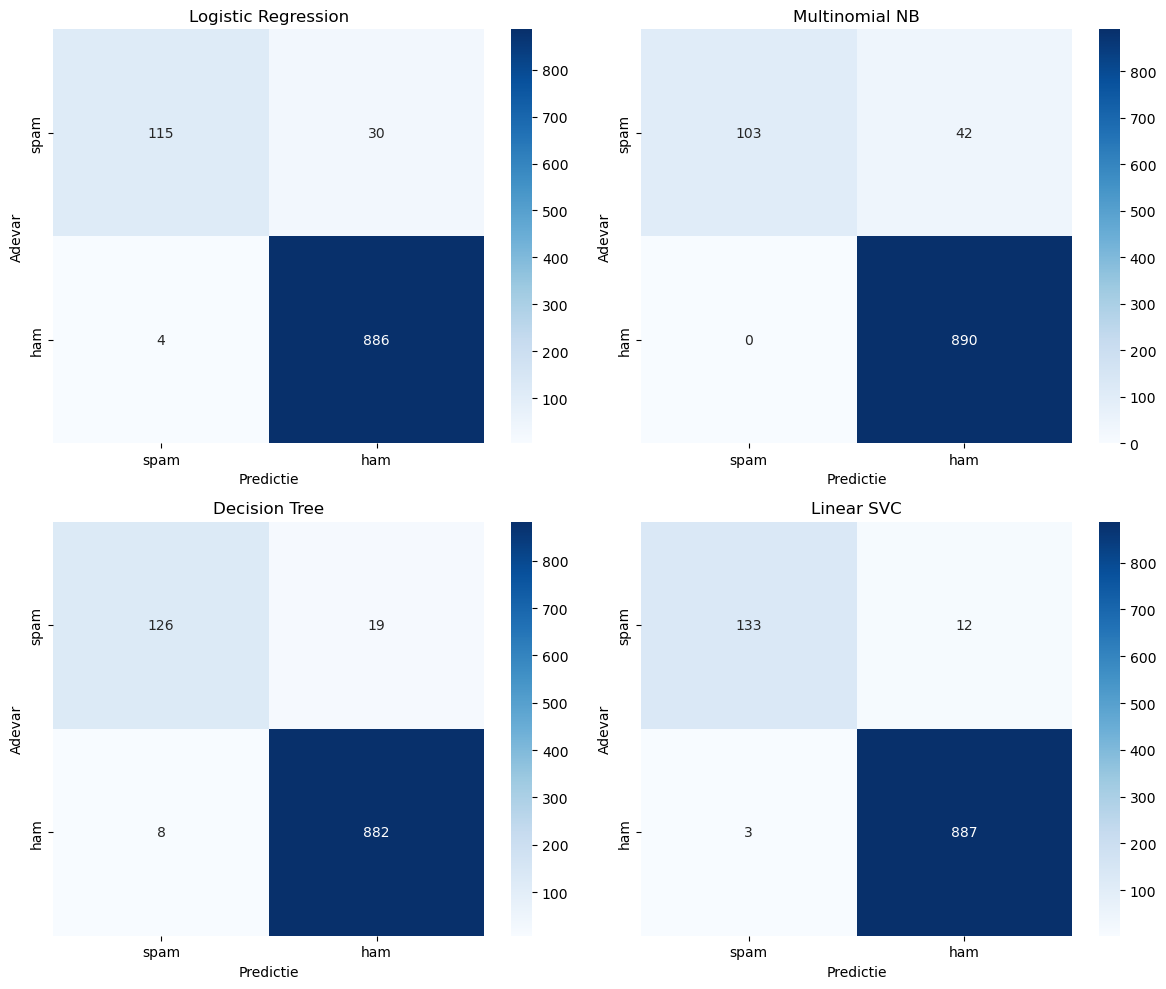

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, info) in zip(axes, results.items()):
    sns.heatmap(info["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["spam", "ham"],
                yticklabels=["spam", "ham"],
                ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predictie")
    ax.set_ylabel("Adevar")

plt.tight_layout()
plt.show()

# Concluzie

Pe baza rezultatelor obtinute, modelul Linear SVC este cel mai de incredere pentru detectarea mesajelor spam. Deoarece are:
 - cea mai mare acuratete: 0.9855
 - cel mai bun F1 pentru spam: 0.95
 - cel mai mic numar de spam ratate (false negative): 12
 - cel mai mic numar de ham clasificate ca spam (false positive): 3

Celelalte modele au avut performante bune, dar cu limitari clare:
 - Logistic Regression a avut acuratete ridicata, insa a ratat mai multe mesaje spam
 - Multinomial Naive Bayes a fost fost foarte rapid, dar a avut cel mai slab recall pentru spam
 - Decision Tree a avut rezultate bune, dar mai putin stabile si cu mai multe greseli decat Linear SVC

Pentru aceasta sarcina, cel mai important lucru a fost ca modelul sa nu lase mesaje spam sa treaca neobservate. De aceeas m-am uitat in special la cat de bine reuseste sa le gaseasca. Am tinut cont si de scorul F1, care arata cat de bine sunt echilibrate greselile si rezultatele corecte. Tinand cont de toate acestea, Linear SVC este modelul care ofera cele mai bune rezultate si este cea mai sigura alegere pentru echipa.
